### **Reporte de Laboratorio 5 - Repaso Examen 1**

Eres analista en la empresa de e-commerce **NovaMarket** y te solicitan un análisis del comportamiento de las ventas y clientes en los últimos 5 meses (septiembre 2024 - febrero 2025).

Te proporcionan los siguientes datasets:

**Ventas**
- **id_cliente**: Número único de registro del cliente.
- **fecha**: Fecha en la que se realizó la compra.
- **id_orden**: Número único de orden.
- **mxn**: Cantidad de pesos gastados.

**Clientes**
- **id_cliente**: Número único de registro del cliente.
- **id_state**: Número único de estado que hace referencia al lugar de residencia del cliente.
- **gender**: (Hombre | Mujer).
- **edad**: Edad del cliente en 2025.

**Estado**
- **id_estado**: Número único de estado.
- **estado**: Nombre del estado.
- **id_region**: Número único de región.

**Región**
- **id_region**: Número único de región.
- **region**: Nombre de la región.


In [197]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as ticker

In [199]:
sns.set_style("darkgrid")

custom_palette = ["#34495E", "#2980B9", "#27AE60", "#F39C12", "#E74C3C"]

sns.set_palette(custom_palette)

pd.options.display.float_format = "{:.2f}".format

In [3]:
ventas = pd.read_excel('./novamarket_repaso.xlsx', sheet_name= 'ventas')
clientes = pd.read_excel('./novamarket_repaso.xlsx', sheet_name= 'clientes')
estado = pd.read_excel('./novamarket_repaso.xlsx', sheet_name= 'estados')
region = pd.read_excel('./novamarket_repaso.xlsx', sheet_name= 'region')

**Realiza cada uno de los puntos solicitados**

1.- Revisa si existen datos nulos en cada uno de los datasets y realiza la imputación correspondiente en caso de ser necesario.

In [4]:
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id_cliente  445 non-null    int64         
 1   fecha       445 non-null    datetime64[ns]
 2   id_orden    445 non-null    object        
 3   mxn         433 non-null    float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 14.0+ KB


Dado que la variable que cuenta con valores faltantes no supera el 5% podemos proceder con un proceso de imputación. 

Evaluaremos cual es su sesgo para poder evaluar cuál es la metodología de imputación

In [5]:
ventas.isna().sum()/len(ventas)

id_cliente   0.00
fecha        0.00
id_orden     0.00
mxn          0.03
dtype: float64

En este caso la media es mayor que la mediana quiere decir que el sesgo tiene una inclinación a la derecha

In [6]:
ventas["mxn"].describe()

count   433.00
mean    537.56
std     176.03
min      85.00
25%     414.00
50%     529.00
75%     687.00
max     888.00
Name: mxn, dtype: float64

Mi sesgo se encuentra entre el rango [1,-1] por tanto puedo asumir que sigue una distribución normal

In [7]:
 ventas["mxn"].skew()

-0.16799275763460864

In [8]:
ventas["mxn"] = ventas["mxn"].fillna(ventas["mxn"].mean())

In [9]:
ventas["mxn"].isnull().sum()/len(ventas)

0.0

Estamos libres de valores nulos ahora

In [10]:
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_client  200 non-null    int64 
 1   id_sate    200 non-null    int64 
 2   gender     200 non-null    object
 3   age        200 non-null    int64 
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [11]:
estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_estado  29 non-null     int64 
 1   estado     29 non-null     object
 2   id_region  29 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 824.0+ bytes


In [12]:
region.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_region  8 non-null      int64 
 1   region     8 non-null      object
dtypes: int64(1), object(1)
memory usage: 256.0+ bytes


Ahora con nuestros resultados podemos concluir que solo la tabla de ventas tenía valores nulos

2.- Revisa si existen datos duplicados en cada uno de los datasets. En caso de que existan, decide qué acciones tomar.**

- Revisa si toda la fila está duplicada.
  - Ejemplo: Registros exactamente iguales.
  
- Verifica los datos duplicados según la granularidad de cada dataset:
  - Ejemplo: La base de ventas está a nivel de orden, por lo que no deben existir "id_orden" duplicados.

In [13]:
ventas.head()

,id_cliente,fecha,id_orden,mxn
0,1,2024-09-05,O1,654.00
1,1,2024-10-08,O2,871.00
2,1,2024-09-17,O3,613.00
3,1,2024-09-22,O4,868.00
4,1,2024-11-24,O5,606.00


In [14]:
ventas.duplicated().sum()

0

In [15]:
ventas["id_orden"].duplicated().sum()

0

In [16]:
clientes.duplicated().sum()

0

In [17]:
clientes["id_client"].duplicated().sum()

0

In [18]:
estado.duplicated().sum()

0

In [19]:
estado["id_estado"].duplicated().sum()

2

In [20]:
estado[estado["id_estado"].duplicated()]

,id_estado,estado,id_region
10,10,Jalisco,4
11,10,Jalisco,8


In [21]:
estado[estado["id_estado"] == 10]

,id_estado,estado,id_region
9,10,Jalisco,5
10,10,Jalisco,4
11,10,Jalisco,8


In [22]:
region

,id_region,region
0,1,Centronorte
1,2,Centrosur
2,3,Noreste
3,4,Noroeste
4,5,Occidente
5,6,Oriente
6,7,Sureste
7,8,Suroeste


In [23]:
estado.drop([10, 11], inplace = True)
estado[estado["id_estado"] == 10]

,id_estado,estado,id_region
9,10,Jalisco,5


In [24]:
region.duplicated().sum()

0

3.- Una buena práctica al trabajar con datos es mantener la consistencia en los nombres de las columnas. Cambia los nombres de las columnas de los datasets según corresponda.


In [25]:
ventas.columns

Index(['id_cliente', 'fecha', 'id_orden', 'mxn'], dtype='object')

In [26]:
clientes.columns

Index(['id_client', 'id_sate', 'gender', 'age'], dtype='object')

In [27]:
estado.columns

Index(['id_estado', 'estado', 'id_region'], dtype='object')

In [28]:
region.columns

Index(['id_region', 'region'], dtype='object')

In [29]:
ventas.rename(columns = {'id_client':'id_cliente'}, inplace = True)
ventas.columns

clientes.rename(columns = {"id_client":"id_cliente"}, inplace = True)
clientes.columns

Index(['id_cliente', 'id_sate', 'gender', 'age'], dtype='object')

In [30]:
clientes.rename(columns = {'id_sate':'id_estado'}, inplace = True)
clientes.columns

Index(['id_cliente', 'id_estado', 'gender', 'age'], dtype='object')

4.- Genera un dataset completo con los siguientes datos:

Base de datos a nivel de orden:
- **id_cliente**: Número único de registro del cliente.
- **fecha**: Fecha en la que se realizó la compra.
- **id_orden**: Número único de la orden.
- **mxn**: Cantidad de pesos gastados.
- **gender**: (Hombre | Mujer).
- **edad**: Edad del cliente en 2025.
- **estado**: Nombre del estado de residencia.
- **region**: Región de residencia.

In [31]:
ventas.columns

Index(['id_cliente', 'fecha', 'id_orden', 'mxn'], dtype='object')

In [32]:
# Fixing the issue by specifying suffixes for overlapping column names during the join operation.
df = ventas.join(clientes.set_index('id_cliente'), on='id_cliente', how='left', lsuffix='_ventas', rsuffix='_clientes')
df = df.merge(estado, on='id_estado', how='left')
df = df.merge(region, on='id_region', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id_cliente  445 non-null    int64         
 1   fecha       445 non-null    datetime64[ns]
 2   id_orden    445 non-null    object        
 3   mxn         445 non-null    float64       
 4   id_estado   445 non-null    int64         
 5   gender      445 non-null    object        
 6   age         445 non-null    int64         
 7   estado      445 non-null    object        
 8   id_region   445 non-null    int64         
 9   region      445 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(4)
memory usage: 34.9+ KB


In [33]:
clientes.columns

Index(['id_cliente', 'id_estado', 'gender', 'age'], dtype='object')

5.- ¿Cuál es la región con mayor cantidad de clientes en 2025?

In [34]:
df["fecha"] = pd.to_datetime(df["fecha"])

df["year"] = df["fecha"].dt.year
df["month"] = df["fecha"].dt.month

grouped_clientes = df[df["year"] == 2025].groupby(["region"]).agg({
    "id_cliente": "nunique",
})

grouped_clientes.reset_index(inplace=True)

grouped_clientes

,region,id_cliente
0,Centronorte,9
1,Centrosur,20
2,Noreste,7
3,Noroeste,18
4,Occidente,19
5,Oriente,17
6,Sureste,3


6.- ¿Cuál es la región con mayor cantidad de ventas (mxn) en 2025?

In [35]:
grouped_ventas = df[df["year"] == 2025].groupby(["region"]).agg({
    "mxn" : "sum"
})

grouped_ventas.reset_index(inplace=True)

grouped_ventas

,region,mxn
0,Centronorte,7503.00
1,Centrosur,21958.00
2,Noreste,3383.56
3,Noroeste,14885.56
4,Occidente,14634.56
5,Oriente,7114.00
6,Sureste,526.00


 7.- Crea una tabla que muestre el total de ventas de la empresa por cada mes. Interpreta los resultados.


In [36]:
grouped_mes = df.groupby(["year", "month"]).agg({
    "mxn" : "sum"
})

grouped_mes = df.groupby(["year", "month"])
df_grouped_mes = grouped_mes["mxn"].sum().round(2)
df_grouped_mes

year  month
2024  9       42548.24
      10      42611.12
      11      43115.12
      12      40934.56
2025  1       36302.68
      2       33702.00
Name: mxn, dtype: float64

8.- En una sola gráfica, muestra la tendencia de las ventas a través de los meses para cada una de las regiones. Interpreta los resultados.


In [37]:
df_grouped_mes = df_grouped_mes.reset_index()
df_grouped_mes

,year,month,mxn
0,2024,9,42548.24
1,2024,10,42611.12
2,2024,11,43115.12
3,2024,12,40934.56
4,2025,1,36302.68
5,2025,2,33702.00


In [38]:
df_grouped_mes["fecha"] = pd.to_datetime(df_grouped_mes[["year", "month"]].assign(day=1))
df_grouped_mes

,year,month,mxn,fecha
0,2024,9,42548.24,2024-09-01
1,2024,10,42611.12,2024-10-01
2,2024,11,43115.12,2024-11-01
3,2024,12,40934.56,2024-12-01
4,2025,1,36302.68,2025-01-01
5,2025,2,33702.00,2025-02-01


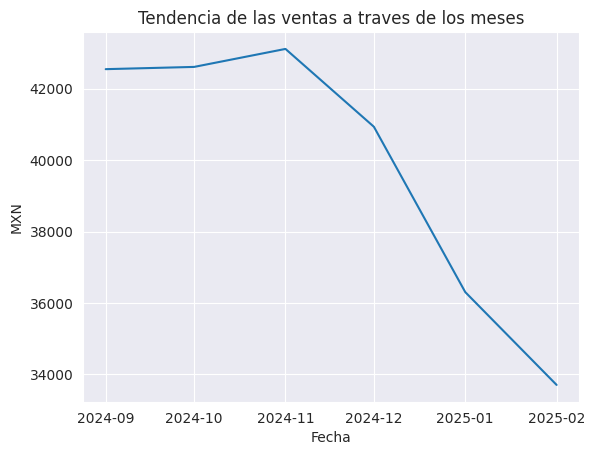

In [39]:
plt.plot(df_grouped_mes["fecha"], df_grouped_mes["mxn"])

plt.title("Tendencia de las ventas a traves de los meses")
plt.xlabel("Fecha")
plt.ylabel("MXN")

plt.show()

9.- En una sola gráfica, muestra la tendencia de las ventas a través de los meses para cada género de los clientes. Interpreta los resultados.


10.- Crea una tabla que muestre el promedio de ventas por orden para cada región. Interpreta los resultados.

In [46]:
df_grouped_mes_gender = df.groupby([pd.Grouper(key="fecha", freq="M"), "gender"]).agg({
    "mxn" : "sum"
})

df_grouped_mes_gender = df_grouped_mes_gender.reset_index()
df_grouped_mes_gender

,fecha,gender,mxn
0,2024-09-30,Hombre,8673.12
1,2024-09-30,Mujer,33875.12
2,2024-10-31,Hombre,13774.00
3,2024-10-31,Mujer,28837.12
4,2024-11-30,Hombre,16748.00
5,2024-11-30,Mujer,26367.12
6,2024-12-31,Hombre,9795.56
7,2024-12-31,Mujer,31139.00
8,2025-01-31,Hombre,7617.00
9,2025-01-31,Mujer,28685.68


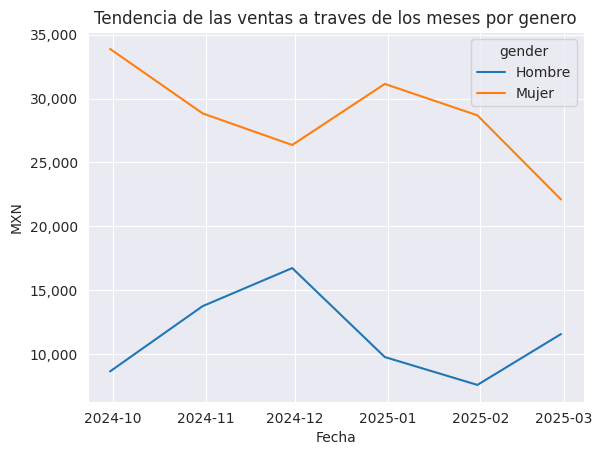

In [54]:
sns.lineplot(df_grouped_mes_gender, x = "fecha", y = "mxn", hue="gender")

plt.title("Tendencia de las ventas a traves de los meses por genero")
plt.xlabel("Fecha")
plt.ylabel("MXN")

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.show()

11.- Crea una tabla que muestre el promedio de ventas por cliente en 2024 para cada región. Interpreta los resultados.

Es decir, el calculo que se nos esta solicitando se refiere a la operacion de que para cada cliente se obtenga el promedio de sus ventas en 2024 por region. Por tanto, tras haber realizado. el codigo una forma más rapida de poder analizar estos resultados se encuentra en la distribucion de los datos, pues su longitud no permita obtener una imagen clara de los resultados, en este sentido se puede apreciar que su distribucion tiene una linea relativamente normal, por tanto quiere decir que se esperaria que sus ventas mantengan la tendencia actual de la distribución pues no habria razon para inferir que habria cambios en las tendencias con las politicas actuales de la empresa.

Por otro lado, si queremos tender la tendencia por cada region debemos de saber si el tamaño de nuestra cada una de las muestras para cada region es relativamente similar una con otra, de esta forma nos aseguramos que el análisis estadistico que se desarrolle sea significativo para poder dar conclusiones sobre el comportamiento de las ventas. lo mas acercadas a la realidad y normalidad de la misma.

En este sentido las unicas regiones que cuentan con muestras significativas son las que corresponden a las siguientes regiones:
- Noroeste
- Occidente
- Centro sur

Por tanto, a la hora de obtener el detalle de los resultados por region, es decir una perpectiva con un nivel más alto, existe la posbiliad de que podamos sesgar nuestros resultados sobre las demas muestras.

In [86]:
df_promedio_ventas_clientes = df[df["year"] == 2024].groupby(["id_cliente", "region",]).agg(
    mean_ventas = ("mxn", "mean"),
    median_ventas = ("mxn", "median"),
    sum_ventas = ("mxn", "sum"),
    count_ventas = ("mxn", "count"),
    std_ventas = ("mxn", "std"),
).round(2)

df_promedio_ventas_clientes = df_promedio_ventas_clientes.reset_index()
df_promedio_ventas_clientes.sort_values(by=["id_cliente","region"], ascending=False, inplace=True)

df_promedio_ventas_clientes

,id_cliente,region,mean_ventas,median_ventas,sum_ventas,count_ventas,std_ventas
159,200,Centronorte,750.00,752.00,2250.00,3,33.05
158,199,Occidente,648.00,648.00,648.00,1,NaN
157,198,Occidente,513.00,513.00,513.00,1,NaN
156,197,Noreste,448.85,419.00,1346.56,3,78.18
155,196,Centrosur,537.56,537.56,537.56,1,NaN
...,...,...,...,...,...,...,...
4,5,Centronorte,761.00,761.00,761.00,1,NaN
3,4,Occidente,573.59,542.78,3441.56,6,90.39
2,3,Occidente,514.00,514.00,514.00,1,NaN
1,2,Centronorte,738.00,738.00,1476.00,2,16.97


In [88]:
values = df_promedio_ventas_clientes["id_cliente"].unique()
len(values)

160

In [117]:
df_promedio_ventas_clientes["region"].value_counts()

region
Noroeste       34
Occidente      32
Centrosur      31
Oriente        21
Centronorte    21
Noreste        16
Sureste         5
Name: count, dtype: int64

In [115]:
df_promedio_ventas_clientes["region"].value_counts()/len(df_promedio_ventas_clientes)

region
Noroeste      0.21
Occidente     0.20
Centrosur     0.19
Oriente       0.13
Centronorte   0.13
Noreste       0.10
Sureste       0.03
Name: count, dtype: float64

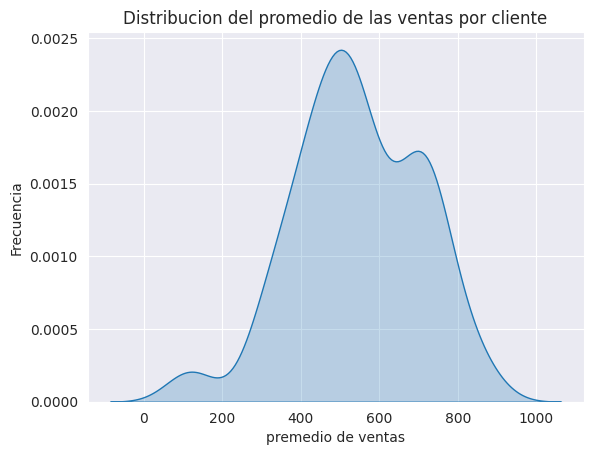

In [107]:
sns.kdeplot(df_promedio_ventas_clientes, x="mean_ventas", fill=True)

plt.title("Distribucion del promedio de las ventas por cliente")

plt.xlabel("premedio de ventas")
plt.ylabel("Frecuencia")

plt.show()

In [105]:
df_promedio_ventas_clientes["mean_ventas"].skew()

-0.2683174665625906

12.- Crea una tabla que muestre el promedio de ventas por mes para cada región. Interpreta los resultados.



Interpretando los resultados podemos identificar claramente una distancia diametralmente opuesta entre los resultados de cada region. Siendo la suroestre la que posee una menos cantidad de ventas a lo largo de estos meses, lo que puede indicar que debe de existir un factor que se encuentra mermando la eficiencia y rentabilidad de esta ubicacion.

Siendo que los resultados de la región Suroeste representan únicamente un tercio de los obtenidos en la penúltima región Oriente.

In [78]:
df_grouped_region = df.groupby(["region"]).agg(
    mxn_sum = ("mxn","sum"),
    mxn_mean = ("mxn","mean"),
    mxn_median = ("mxn","median"),
    mxn_count = ("mxn","count"),
    mxn_std = ("mxn","std")
).round(0)

df_grouped_region = df_grouped_region.reset_index()
df_grouped_region.sort_values(by=["mxn_mean"], ascending=False, inplace=True)
df_grouped_region

,region,mxn_sum,mxn_mean,mxn_median,mxn_count,mxn_std
1,Centrosur,68611.00,738.00,726.00,93,89.00
0,Centronorte,32665.00,681.00,712.00,48,72.00
4,Occidente,47254.00,576.00,562.00,82,108.00
3,Noroeste,49284.00,498.00,497.00,99,45.00
2,Noreste,17026.00,415.00,411.00,41,30.00
5,Oriente,22085.00,345.00,334.00,64,59.00
6,Sureste,2289.00,127.00,130.00,18,30.00


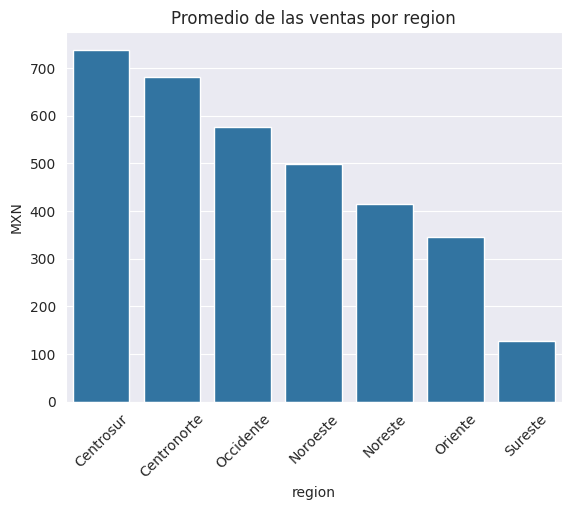

In [121]:
sns.barplot(df_grouped_region, x="region", y="mxn_mean")

plt.title("Promedio de las ventas por region")
plt.xlabel("region")
plt.ylabel("MXN")

plt.xticks(rotation=45)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:,.0f}'))

plt.show()

13.- Crea una gráfica que muestre la distribución de las ventas por orden para cada región. Interpreta los resultados.

Para interpretar los resultados yo decidi proyecar los datos en dos formatos que tiene la misma instencion a la hora de construirse. Hablarte sobre la distribución de los datos. En este sentid, el histograma y los kernel density son las dos piezas que yo necesite para poder llegar a una sensilla conclusion. Que primero hay que dividir los datos en dos grupos o sino es ilegible, por tanto, ya despues de tener ambas proyecciones se puede apreciar que las regiones de oriente tiene una distribucción bastante concentrada y tambien con una media vastante alejada del centro

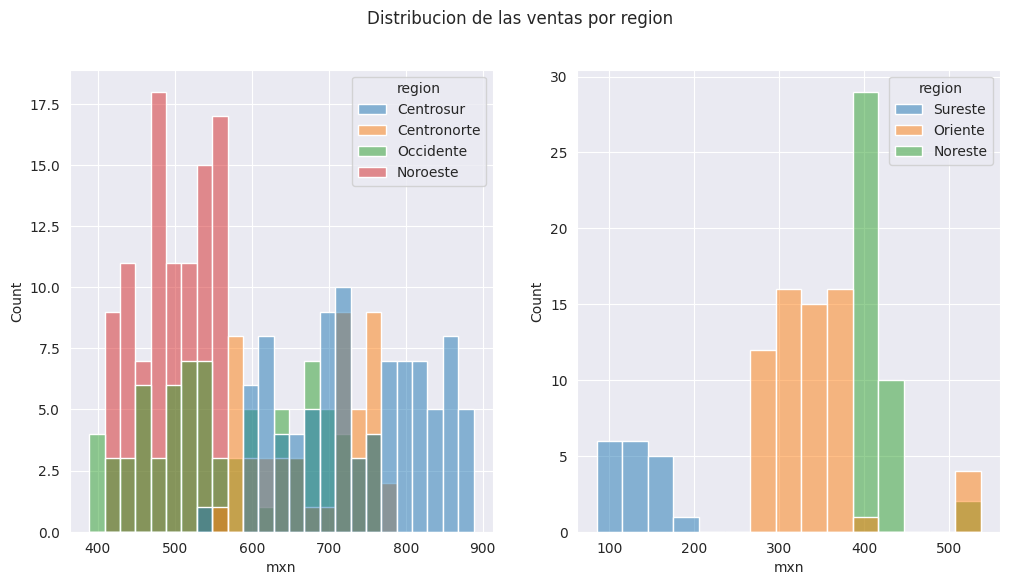

In [146]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

df1 = df[df["region"].isin(["Centrosur", "Centronorte", "Occidente", "Noroeste"])]
df2 = df[~df["region"].isin(["Centrosur", "Centronorte", "Occidente", "Noroeste"])]

sns.histplot(df1, x="mxn", hue="region", ax=ax1, bins=25)
sns.histplot(df2, x="mxn", hue="region", ax=ax2, bins=15)

fig.suptitle("Distribucion de las ventas por region")

plt.show()

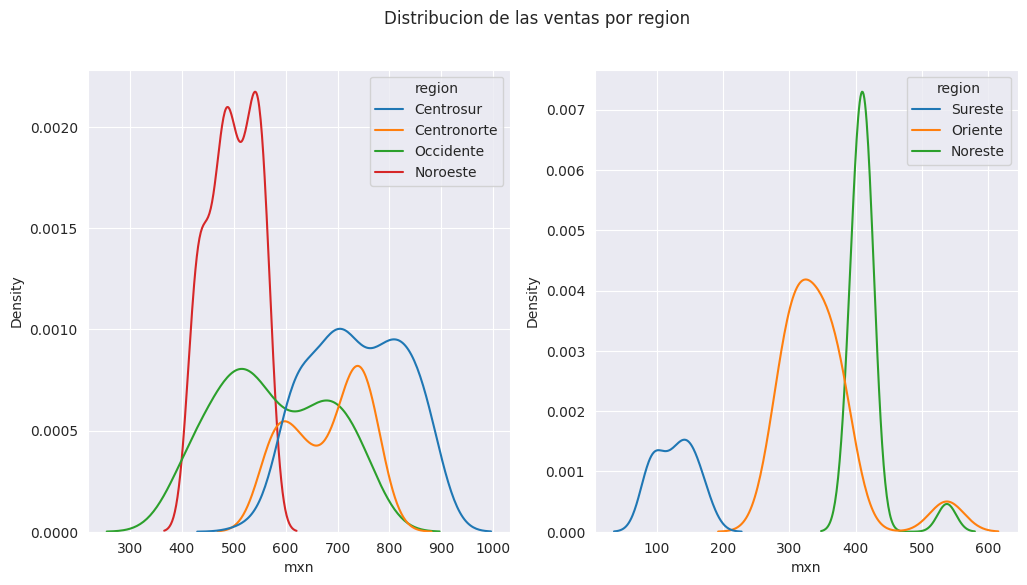

In [149]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

df1 = df[df["region"].isin(["Centrosur", "Centronorte", "Occidente", "Noroeste"])]
df2 = df[~df["region"].isin(["Centrosur", "Centronorte", "Occidente", "Noroeste"])]

sns.kdeplot(df1, x="mxn", hue="region", ax=ax1, )
sns.kdeplot(df2, x="mxn", hue="region", ax=ax2, )

fig.suptitle("Distribucion de las ventas por region")

plt.show()

14.- Genera una gráfica de box-plot que muestre las ventas a nivel de cliente, separadas por género. Interpreta los resultados.

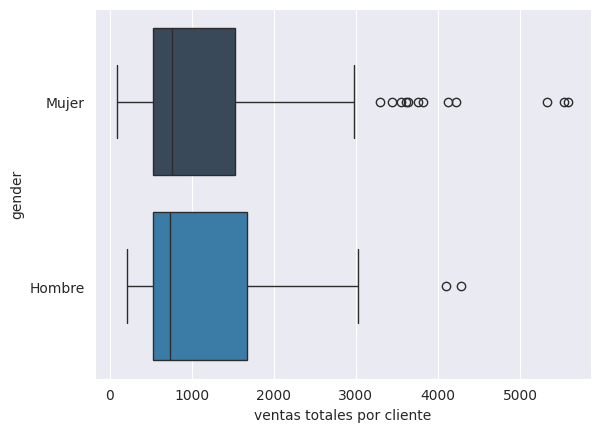

In [201]:
df_grouped_cliente = df.groupby(["id_cliente", "gender"]).agg(
    mxn_sum = ("mxn","sum"),
    mxn_mean = ("mxn","mean"),
)

df_grouped_cliente = df_grouped_cliente.reset_index()
df_grouped_cliente.sort_values(by=["mxn_sum"], ascending=False, inplace=True)

sns.boxplot(df_grouped_cliente, x="mxn_sum", y="gender", vert=False, hue="gender")
plt.xlabel("ventas totales por cliente")

plt.show()

15.- Calcula la métrica de recencia para cada cliente.
- Recencia: Número de días desde la última compra.

**¿Cómo hacerlo?**
- Calcula la última fecha de compra de cada cliente.
- Calcula el número de días que han pasado desde la última compra hasta el 28 de febrero de 2025.

In [175]:
today = pd.to_datetime("2025-02-28")

df_recencia = df.groupby(["id_cliente"]).agg(
    ultima_compra = ("fecha", "max"),
    recencia = ("fecha", lambda x : (today - x.max()).days),
    ventas = ("mxn", "sum")
)

df_recencia = df_recencia.reset_index()
df_recencia.sort_values(by=["recencia"], ascending=False, inplace=True)

df_recencia

,id_cliente,ultima_compra,recencia,ventas
17,18,2024-09-03,178,730.00
62,63,2024-09-04,177,504.00
77,80,2024-09-04,177,492.00
191,199,2024-09-04,177,648.00
131,135,2024-09-04,177,512.00
...,...,...,...,...
162,170,2025-02-26,2,4120.56
128,132,2025-02-27,1,593.00
31,32,2025-02-27,1,5542.00
58,59,2025-02-28,0,380.00


16.- Realiza una gráfica de dispersión que muestre la relación entre la recencia y la cantidad de MXN comprados por los clientes. Interpreta los resultados.

No existe una correlacion de algun tipo entre el tiempo que tardan los clientes en volver a realizar una compra y la cantidad de dinero que gastan en cada una de estas.

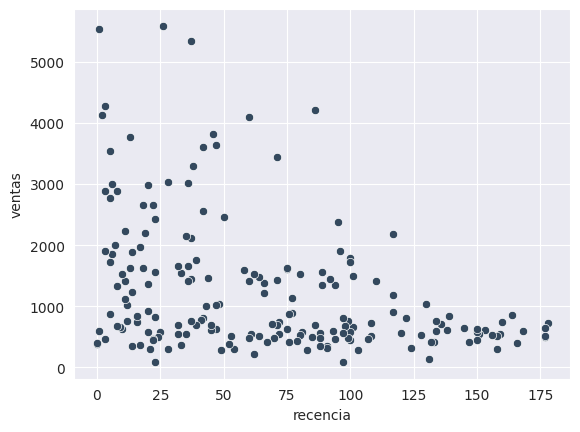

In [208]:
sns.scatterplot(df_recencia, x="recencia", y="ventas")

plt.show()

In [210]:
np.corrcoef(df_recencia["recencia"], df_recencia["ventas"])

array([[ 1.        , -0.38009663],
       [-0.38009663,  1.        ]])

17.- Realiza una gráfica de barras que muestre la recencia promedio de los clientes en cada uno de los estados. Interpreta la gráfica.

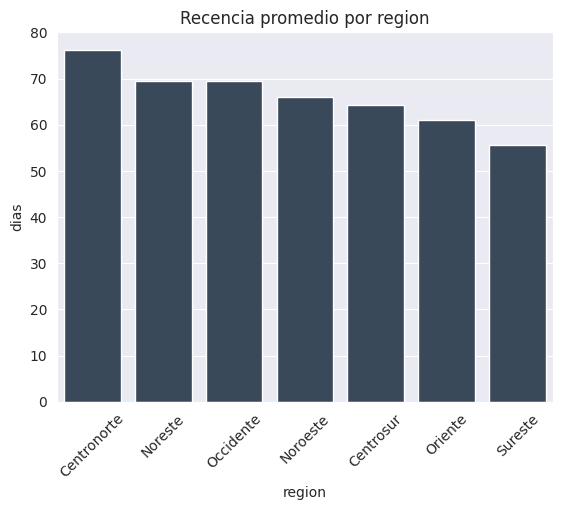

In [218]:
df_recencia_estado = df.groupby(["id_cliente", "region"]).agg(
    ultima_compra = ("fecha", "max"),
    recencia = ("fecha", lambda fecha : (today - fecha.max()).days)   
)

df_recencia_estado = df_recencia_estado.reset_index()
df_recencia_estado = df_recencia_estado.groupby(["region"]).agg(
    recencia_promedio = ("recencia", "mean")
)

df_recencia_estado = df_recencia_estado.reset_index()
df_recencia_estado.sort_values(by=["recencia_promedio"], ascending=False, inplace=True)

sns.barplot(df_recencia_estado, x="region", y="recencia_promedio")

plt.title("Recencia promedio por region")
plt.xlabel("region")
plt.ylabel("dias")

plt.xticks(rotation=45)

plt.show()

18.- ¿Cuál es el estado con la mayor cantidad de ventas en diciembre de 2024?

In [228]:
df_ventas_estado = df[df["fecha"].dt.month == 12].groupby("region").agg(
    mxn_sum = ("mxn", "sum")
)

df_ventas_estado = df_ventas_estado.reset_index()
df_ventas_estado.sort_values(by=["mxn_sum"], ascending=False, inplace=True)

df_ventas_estado.iloc[0,:]

region     Centrosur
mxn_sum     11039.56
Name: 1, dtype: object

In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 445 entries, 0 to 444
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id_cliente  445 non-null    int64         
 1   fecha       445 non-null    datetime64[ns]
 2   id_orden    445 non-null    object        
 3   mxn         445 non-null    float64       
 4   id_estado   445 non-null    int64         
 5   gender      445 non-null    object        
 6   age         445 non-null    int64         
 7   estado      445 non-null    object        
 8   id_region   445 non-null    int64         
 9   region      445 non-null    object        
 10  year        445 non-null    int32         
 11  month       445 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(2), int64(4), object(4)
memory usage: 38.4+ KB


19.- ¿Cuál es el estado con la menor desviación estándar de ventas por orden?

In [238]:
df_std_estado = df.groupby(["region"]).agg(
    mxn_std = ("mxn", "std")
)

df_std_estado.reset_index(inplace=True)
df_std_estado.sort_values(by=["mxn_std"], inplace=True)

df_std_estado.iloc[0,:]

region     Sureste
mxn_std      29.57
Name: 6, dtype: object

20.- ¿Cuáles son los 3 estados con la mayor venta mensual promedio por cliente?

In [246]:
df_venta_mensual_cliente = df.groupby(["region"]).agg(
    mxn_median = ("mxn", "mean")
)

df_venta_mensual_cliente.reset_index(inplace=True)
df_venta_mensual_cliente.sort_values(by=["mxn_median"], ascending=False, inplace=True)

df_venta_mensual_cliente.head(3)

,region,mxn_median
1,Centrosur,737.75
0,Centronorte,680.52
4,Occidente,576.27


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=52d42f7b-e3e4-4fa6-bf85-d2691d7edf9a' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>